In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer
from sklearn.metrics import confusion_matrix, accuracy_score
import os
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
stem = PorterStemmer().stem
import string
from scipy.sparse import csr_matrix
from unidecode import unidecode

In [2]:
from scipy.sparse import hstack, vstack

In [3]:
for dirname, _, filenames in os.walk('./kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

./kaggle/input\comment-category-prediction-challenge\Sample.csv
./kaggle/input\comment-category-prediction-challenge\test.csv
./kaggle/input\comment-category-prediction-challenge\train.csv


### EDA

In [4]:
df = pd.read_csv('./kaggle/input/comment-category-prediction-challenge/train.csv')

In [5]:
df = df.replace('none',np.nan)

In [6]:
df.isnull().sum()

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            185105
religion        183672
gender          181584
disability           0
comment              1
label                0
dtype: int64

In [7]:
df['gender'].unique(), df['race'].unique(), df['religion'].unique()

(array([nan, 'male', 'female', 'transgender', 'other'], dtype=object),
 array([nan, 'white', 'other', 'asian', 'black', 'latino'], dtype=object),
 array([nan, 'christian', 'muslim', 'jewish', 'atheist', 'other', 'hindu',
        'buddhist'], dtype=object))

#### Null values Analysis
As comment is the most important feature here, the one row without comment can be dropped
As for race, gender, and religion, 'none' to be replaced with nan

In [8]:
df.columns

Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'label'],
      dtype='object')

In [9]:
df.if_1.sort_values().unique()

array([   0,    4,    5,    6,    7,    8,    9,   10,   11,   12,  249,
        250, 1232, 1254, 1256, 1257, 1258, 1263, 1267, 1271, 1277, 1538,
       1543, 1545, 1547, 1548, 1551, 1553, 1557, 1558, 1560, 1566, 1569,
       1572, 1576, 1581, 1583, 1584, 1585, 1767, 1777, 1778, 1783, 1800,
       1807, 1810, 1811, 1814, 1815, 1819, 1825, 1827, 1830, 1838, 1846,
       1848, 1860])

In [10]:
df['emoticon_1'].unique()

array([ 0,  1, 15,  2,  3,  4,  5, 11,  6,  7,  8, 24, 12, 17, 14, 13,  9,
       10, 20, 16, 25, 18, 21, 19, 23, 36, 22, 28, 27, 33, 30, 46, 32, 47,
       31, 39])

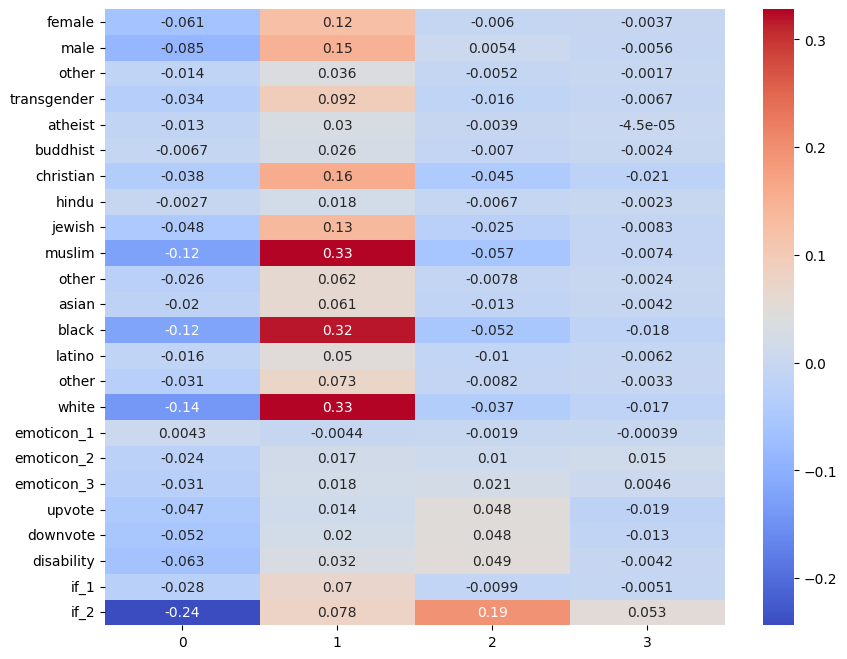

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

hm = pd.concat([
    pd.get_dummies(df['label']).astype(int),
    pd.get_dummies(df['gender']).astype(int),
    pd.get_dummies(df['religion']).astype(int),
    pd.get_dummies(df['race']).astype(int),
    df[['emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote','disability','if_1', 'if_2']]], 
          axis=1).corr() \
    .iloc[[0,1,2,3],4:].transpose()

sns.heatmap(hm, annot=True, cmap='coolwarm',)
plt.show()

#### Features to Ignore
1. Created_date: Although time of comment can be argued to be of some use, it's a long shot
2. post_id
3. emoticons: not very clear what the values represent. Intensity of the feature, or index of some value of the feature.
    (While milestones did consider these to be intensity/value, the correlation is not enough to consider these as valid features)

<Axes: ylabel='Frequency'>

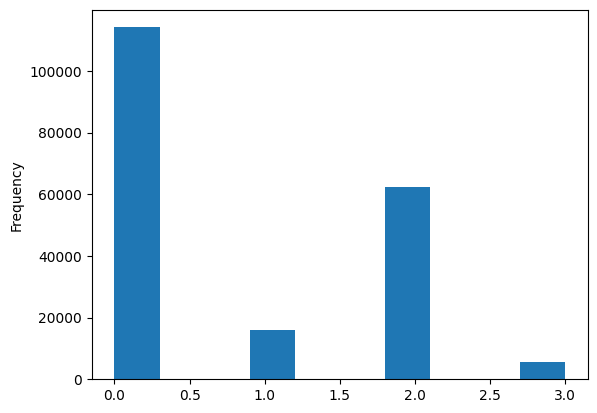

In [12]:
df['label'].plot(kind='hist')

### Data Preprocessing

In [13]:
stop_words = stopwords.words('english')

In [14]:
def clean_text(text):
    text = unidecode(text)
    text = str(text).lower()
    text = str(text).translate(str.maketrans(string.punctuation,' '*len(string.punctuation)))
    text = str(text).translate(str.maketrans('','', string.digits))    
    text = text.split()
    text = " ".join([stem(i) for i in text]) # if len(i)>2 and len(i)<15]  #  if i not in stop_words
    return text


In [15]:
# Dropping Unnecessary columns, and rows
df = df.drop(['post_id', 'created_date'], axis=1)
df = df.drop(df[df['comment'].isnull()].index).reset_index(drop=True)

In [16]:
# Replacing 'none' with nan
# df[['race', 'religion', 'gender']] = df[['race', 'religion', 'gender']].replace(np.nan,'')

In [17]:
df.isna().sum()

emoticon_1         0
emoticon_2         0
emoticon_3         0
upvote             0
downvote           0
if_1               0
if_2               0
race          185104
religion      183671
gender        181583
disability         0
comment            0
label              0
dtype: int64

In [18]:
train_df, val_df = train_test_split(df, test_size=.1, stratify=df['label'], random_state=42)

In [19]:
x_train, y_train = train_df[['emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment']], train_df['label']

In [20]:
x_val, y_val = val_df[['emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment']], val_df['label']

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.pipeline import Pipeline


In [22]:
from sklearn.decomposition import TruncatedSVD

In [23]:
text_pipeline = Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='')),
    ('reshape', FunctionTransformer(lambda x: x.ravel())),
    ('tfidf', TfidfVectorizer(preprocessor=clean_text, min_df=2)),
    # ('to_numpy', FunctionTransformer(lambda x: x.toarray()))
    ])

In [31]:
categorical_cols = ["race", "religion", "gender", "disability"]
categorical_pipeline = [("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True))]


numerical_cols = ["upvote", "downvote", "if_1", "if_2"] #"emoticon_1", "emoticon_2", "emoticon_3",
numerical_pipeline = [("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())]

categorical_pipeline = Pipeline(categorical_pipeline)
numerical_pipeline = Pipeline(numerical_pipeline)


preprocessor = ColumnTransformer(
    transformers=[("cat", categorical_pipeline, categorical_cols),
        ("num", numerical_pipeline, numerical_cols),
        ("text", text_pipeline, ['comment'])],
    remainder="passthrough"
)

In [32]:
x_train_matrix = preprocessor.fit_transform(x_train)

In [33]:
x_val_matrix = preprocessor.transform(x_val)

from sklearn.decomposition import TruncatedSVD
svd = TruncatedSVD(n_components=300, random_state=2306)

X_train_reduced = svd.fit_transform(x_train_matrix)
X_test_reduced = svd.transform(x_val_matrix)

from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=1, random_state=42)
clf.fit(x_train_matrix, y_train)
y_pred = clf.predict(x_val_matrix)
confusion_matrix(y_val, y_pred)
accuracy_score(y_val, y_pred)

In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier


clf2 = MLPClassifier((16,), verbose=True, max_iter=2,random_state=42, warm_start=True, activation='tanh')

clf3 = MLPClassifier((4, 32), verbose=True, max_iter=2,random_state=42, warm_start=True, activation='tanh')
clf3.fit(x_train_matrix, y_train)


y_pred2 = clf3.predict(x_val_matrix)

print(confusion_matrix(y_val, y_pred2))
print(accuracy_score(y_val, y_pred2))

clf2.fit(vstack([x_train_matrix,x_val_matrix]), pd.concat([y_train, y_val]))
#clf2.fit(x_train_matrix, y_train)

y_pred2 = clf2.predict(x_val_matrix)

confusion_matrix(y_val, y_pred2)

In [28]:
import itertools

In [34]:
results = {}
params = {'hidden_layer_sizes': ((4,8),(4,16),(4,32),(4,64),(4,),(16,)), 'activation':['tanh','relu']}
for i, (hls,act) in enumerate(itertools.product(params['hidden_layer_sizes'], params['activation'])):
    print(hls, act)
    
    mlp = MLPClassifier(hls, activation=act, random_state=42,max_iter=2, verbose=True)
    
    mlp.fit(x_train_matrix, y_train)
    results[i] = {'params':(hls, act), 'loss': mlp.loss_, 'accuracy': accuracy_score(mlp.predict(x_val_matrix), y_val)}
    print(results[i])


(4, 8) tanh
Iteration 1, loss = 0.69431599
Iteration 2, loss = 0.29797004
{'params': ((4, 8), 'tanh'), 'loss': np.float64(0.29797003713627346), 'accuracy': 0.9007575757575758}
(4, 8) relu


c:\Users\rramk\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.65966219
Iteration 2, loss = 0.34378283
{'params': ((4, 8), 'relu'), 'loss': np.float64(0.3437828252746211), 'accuracy': 0.8885353535353535}
(4, 16) tanh


c:\Users\rramk\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.64595199
Iteration 2, loss = 0.29701835
{'params': ((4, 16), 'tanh'), 'loss': np.float64(0.2970183541916348), 'accuracy': 0.8997474747474747}
(4, 16) relu


...

c:\Users\rramk\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.62121032
Iteration 2, loss = 0.30581484
{'params': ((16,), 'tanh'), 'loss': np.float64(0.3058148376854368), 'accuracy': 0.9001515151515151}
(16,) relu


c:\Users\rramk\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2) reached and the optimization hasn't converged yet.
  warnings.warn(


Iteration 1, loss = 0.61500092
Iteration 2, loss = 0.30042139
{'params': ((16,), 'relu'), 'loss': np.float64(0.3004213865796407), 'accuracy': 0.8995454545454545}


c:\Users\rramk\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2) reached and the optimization hasn't converged yet.
  warnings.warn(


(16,), 'tanh'

In [35]:
pd.DataFrame(results).transpose().sort_values('accuracy')

,params,loss,accuracy
9,"((4,), relu)",0.480162,0.874949
3,"((4, 16), relu)",0.373437,0.880354
1,"((4, 8), relu)",0.343783,0.888535
8,"((4,), tanh)",0.384275,0.889343
7,"((4, 64), relu)",0.311321,0.891919
6,"((4, 64), tanh)",0.307363,0.893081
11,"((16,), relu)",0.300421,0.899545
2,"((4, 16), tanh)",0.297018,0.899747
10,"((16,), tanh)",0.305815,0.900152
0,"((4, 8), tanh)",0.29797,0.900758


In [36]:
hls, act = pd.DataFrame(results).transpose().sort_values('accuracy').iloc[-1,0]

In [37]:
hls, act

((4, 32), 'relu')

In [38]:
mlp = MLPClassifier(hls, activation=act, random_state=42,max_iter=1, verbose=True, warm_start=True)

In [49]:

mlp.fit(vstack([x_train_matrix,x_val_matrix]), pd.concat([y_train, y_val]))

Iteration 1, loss = 0.20646182


c:\Users\rramk\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(4, 32), max_iter=1, random_state=42,
              verbose=True, warm_start=True)

In [50]:
y_pred = mlp.predict(x_val_matrix)
accuracy_score(y_val, y_pred)

0.9395454545454546

In [51]:
test_df = pd.read_csv('./kaggle/input/comment-category-prediction-challenge/test.csv')

In [52]:
test_df = test_df.drop(['created_date', 'post_id'], axis=1)

In [53]:
x_test_m = preprocessor.transform(test_df)

In [54]:
y_main = pd.read_csv('../submission_5.csv')['label']

In [55]:
y_main_pred = mlp.predict(x_test_m)

In [56]:
accuracy_score(y_main, y_main_pred)

0.9327941176470588

In [57]:
pd.DataFrame({'ID':list(range(1,len(test_df)+1)),'label':mlp.predict(x_test_m)}).to_csv('submission_pc_mlp-4-32-6ep.csv',index=False)

In [ ]:
pd.DataFrame({'ID':list(range(1,len(test_df)+1)),'label':clf.predict(x_test_m)}).to_csv('submission_pc_rf.csv',index=False)